# Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare

# Loading Data

In [6]:
gdp_data = pd.read_csv("data.csv")                               # Read the data from csv file
gdp = np.array(gdp_data["2020"].dropna())                        # Ignore missing data
print("Length of data = ", len(gdp))                             # Length of the data
print("Length of non-negative data = ", np.sum(gdp >= 0))        # Length of non-negative data

Length of data =  257
Length of non-negative data =  257


As expected there are no negative values in the data

# Benford's Law
Benford's law, also known as the Newcomb–Benford law, the law of anomalous numbers, or the first-digit law, is an observation that in many real-life sets of numerical data, the leading digit is likely to be small.
# Benford's Distribution
$$P(d) = log_{10}(d+1) - log_{10}(d)$$
$$P(d) = log_{10}\left( 1 + \frac{1}{d} \right) $$
where, $d \in \{1, 2, ...9\}$ are the leading digits

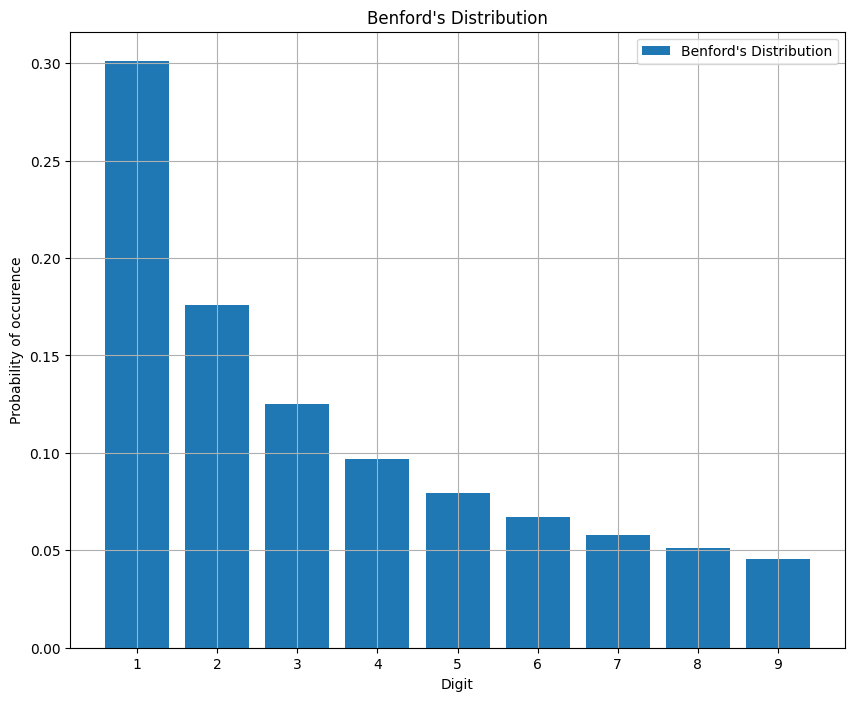

In [14]:
# Benford's distribution
benford_dist = []
digits = np.arange(1, 10)
for d in digits:
    benford_dist.append(np.log10(1 + 1/d))
benford_dist = np.array(benford_dist)

plt.figure(figsize = (10,8))
plt.bar(digits, benford_dist, label = "Benford's Distribution")
plt.title("Benford's Distribution")
plt.xlabel("Digit")
plt.ylabel("Probability of occurence")
plt.xticks(digits)
plt.legend()
plt.grid()
plt.show()

In [8]:
# Function to calculate leading digit
def leading_digit(x):
    if(x < 1 and x != 0):
        while(x < 1):
            x = x*10
            x = x // 1          # To get integer part
    while(x>=10):
        x = x // 10
    return x

In [9]:
# Get leading digits of gdp data
gdp_leading_digits = []
for i in gdp:
    gdp_leading_digits.append(leading_digit(i))

In [10]:
# Counting the number of occurences of each digit in gdp_leading_digits
gdp_counts = []
for d in digits:
    gdp_counts.append(gdp_leading_digits.count(d))
gdp_freqs = gdp_counts/np.sum(gdp_counts)

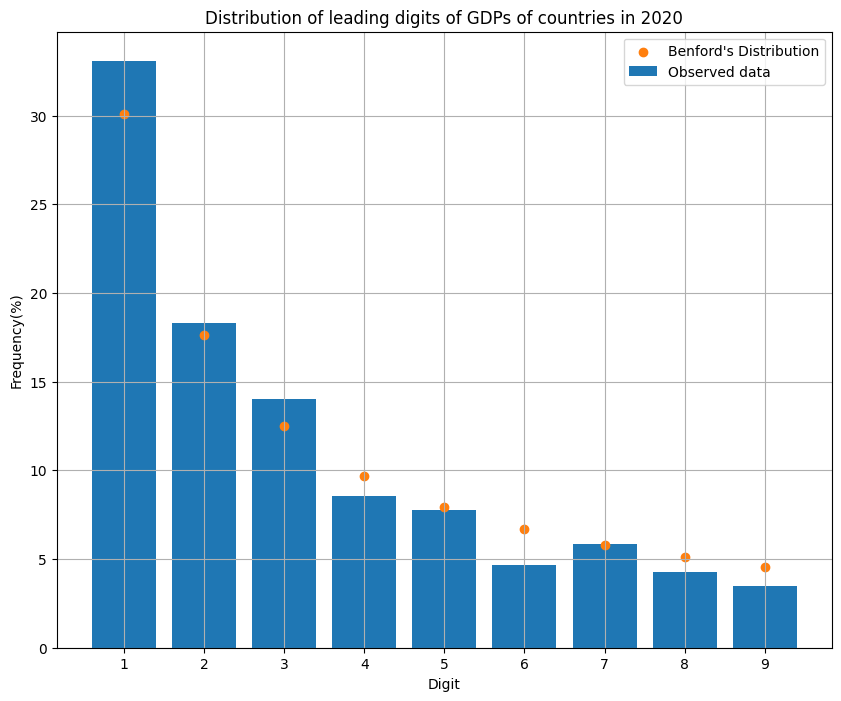

In [11]:
# Plotting distribution of each digit
plt.figure(figsize=(10, 8))
plt.bar(digits, gdp_freqs*100, label = "Observed data")
plt.scatter(digits, benford_dist*100, label = "Benford's Distribution")
plt.title("Distribution of leading digits of GDPs of countries in 2020")
plt.xlabel("Digit")
plt.ylabel("Frequency(%)")
plt.xticks(np.arange(1,10))
plt.legend()
plt.grid()
plt.show()

In [12]:
# Calculating p-value
gdp_chi2_stat, gdp_p_value = chisquare(f_obs = gdp_freqs, f_exp = benford_dist)
print(gdp_p_value)

0.9999999998135671


p-value is greater than 0.05, which suggests us that this data fits to Benford's distribution well.